# Advanced Chemical Reaction Engieering (CBE 60546)
## Homework 4
## Due October 6, 2025

Carefully and neatly document your answers. Use Jupyter/Collab for all plots. See sample code at https://github.com/wmfschneider/CBE60546/blob/main/Resources/Examples.ipynb.

# Its elementary, realy ...

### Q1. Which of the following reactions can be assumed to be elementary? If it is elementary, indicate the molecularity. Briefly Justify your answers.

$$\ce{ O3(g) -> O2(g) + O(g)}$$
$$\ce{ 2H2(g) + O2(g) -> H2O(g)}$$
$$\ce{ 2NO(g) + O2(g) -> 2NO2(g)}$$
$$\ce{ H* + I2 -> HI + I*}$$
$$\ce{ Pt + H2(g) -> 2 Pt-H}$$

In the last example, Pt indicates the surface of a Pt particle and $\ce{Pt-H}$ an H atom bound to the surface.

(1) $\ce{ O3(g) -> O2(g) + O(g)}$ - This **is** an elementary reaction that is unimolecular. $\ce{O}$ atom is not a stable specie and will be used in another step.

(2) $\ce{ 2H2(g) + O2(g) -> 2H2O(g)}$ - This **is not** an elementary reaction. This reaction would require several steps to break and reform bonds of reactants and intermediates.

(3) $\ce{ 2NO(g) + O2(g) -> 2NO2(g)}$ - This **is probably not** an elementary reaction as this too would require three molecules to line up just right! Experimental evidence is inconclusive.

(4) $\ce{ H* + I2 -> HI + I*}$ - This **is** an elementray step that is bimolecular. This step describes the propogation of a radical from one species to another which is completed in a single step.

(5) $\ce{ 2Pt(111) + H2(g) -> 2Pt(111)-H}$ - Assuming the dissosiation occurs as the molecule adsorbs, this **is** a bimolecular elementary reaction. If the $\ce{H2}$ molecule dissociates after adsorption, then it is not an elementary reaction. Effectively depends on conditions that you observe it at.

# Q2. The Path Less Traveled
Chlorine monoxide, $\ce{ClO}$, exhibits three different self-reaction channels:

|     | &emsp;&emsp;$A$ (L mol$^{-1}$s$^{-1}$)&emsp;&emsp; | &emsp;&emsp;$E_{a}$ (kJ mol$^{-1}$)&emsp;&emsp; |
|:--------------------------------:|:----------------------------:|:-----------------------:|
| $\ce{ClO* + ClO*->Cl2 + O2}$     | $ 6.08\times10^{8}   $       |      $13.2$             |
| $\ce{ClO* + ClO*->Cl* + ClOO}$   | $ 1.79\times10^{10}  $       |      $20.4$             |
| $\ce{ClO* + ClO*->Cl* + OClO}$   | $ 2.11\times10^{8}   $       |      $11.4$             |


### Q2.1. Make Arrhenius plots of the three reactions from 150 to 500 K. Which reaction dominates at low temperature? At high temperature?

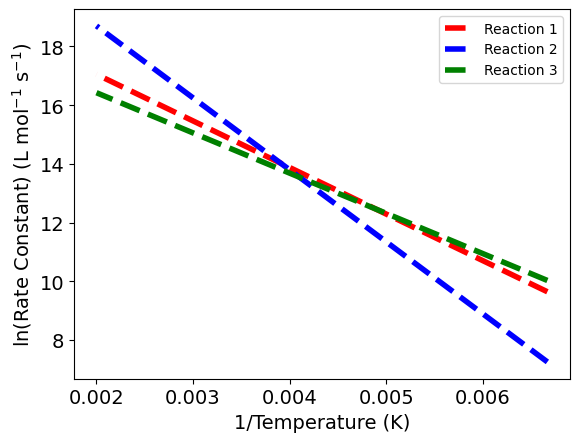

In [1]:
# Answer Here
# Arrhenius equation is: k = A*exp(Ea/R*T) (you can replace R for kb just make units match up correctly)
# Solve for k for a set of T based on the table above

import numpy as np
from scipy import constants # easy way to get physical constants 
import matplotlib.pyplot as plt

# get constants
R = constants.physical_constants['molar gas constant'][0]/1000 # units are kJ mol^-1 K^-1

Temp = np.linspace(150,500,100) # temperature range in K
A = [6.08e8, 1.79e10,2.11e8] # Pre-exponential factor from table
Ea = [13.2,20.4,11.4] # Activation energy from table above

k0=[] # rate constants corresponding to the first reaction
k1=[] # second reaction
k2=[] # third reaction

for t in Temp:
    k0.append(A[0]*np.exp((-1*Ea[0])/(R*t))) # evaluate the Arrhenius equation and save results
    k1.append(A[1]*np.exp((-1*Ea[1])/(R*t)))
    k2.append(A[2]*np.exp((-1*Ea[2])/(R*t)))
    
# Arrhenius plots are present in log form
    
# Make one plot showing the entire range    
plt.plot(1/Temp,np.log(k0),linestyle='dashed',linewidth=4,label='Reaction 1',color='red')   # plot k vs T
plt.plot(1/Temp,np.log(k1),linestyle='dashed',linewidth=4,label='Reaction 2',color='blue')
plt.plot(1/Temp,np.log(k2),linestyle='dashed',linewidth=4,label='Reaction 3',color='green')

plt.xticks(size=14)
plt.yticks(size=14)
plt.xlabel('1/Temperature (K)',size=14)
plt.ylabel(r'ln(Rate Constant) (L mol$^{-1}$ s$^{-1}$)',size=14)
plt.legend()
plt.show()

Reaction 2 dominates at low T; reaction 3 at high T.

### Q2.2. Can collision theory account for the variations in rate constants amongst the three reactions? Why or why not?

No. Collision theory relates rates to rates of collision; it has no way to account for the same colliding species to give different products. 

### Q2.3. The rate constant for a gas-phase bimolecular reaction can be written within transition state theory (using an isobaric standard state) as shown below. Use the definition of $E_{a}$ to derive relationships between the Arrhenius parameters and the standard activation enthalpy, $\Delta H^{\circ,\ddagger}$ and standard activation entropy , $\Delta S^{\circ,\ddagger}$, at 1 bar standard state.

$$ k = \frac{k_{b}T}{h}\left (\frac{RT}{P^{\circ}}\right )\exp\left(\frac{-\Delta G^{\circ,\ddagger}(T)}{k_{b}T}\right )$$

Using the equation above we can do the following: <br>
(1) assuming equilibrium $\Delta G^{\circ \ddagger}(T) = \Delta H^{\circ \ddagger} - T\Delta S^{\circ \ddagger}$ <br>
(2) evaluate the derivate of the function with respect to T <br>
<br>
$$k = \frac{k_{b}T}{h}(\frac{RT}{P^{\circ}})\exp(\frac{-\Delta G^{\circ \ddagger}(T)}{k_{b}T})$$

$$\ln(k) = \ln(\frac{k_{b}RT^2}{hP^{\circ}})+\frac{-\Delta G^{\circ \ddagger}(T)}{k_{b}T}$$

$$\ln(k) = \ln(\frac{k_{b}RT^2}{hP^{\circ}})+\frac{-\Delta H^{\circ \ddagger}}{k_{b}T}+\frac{\Delta S^{\circ \ddagger}}{k_{b}}$$

$$\frac{\partial\ln(k)}{\partial (1/T)} = -2T-\frac{\Delta H^{\circ \ddagger}}{k_{b}}$$

<br>
We can follow the same proceedures for the Arrhenius equation (but it is much simplier)
$$k = A \exp(\frac{-E_a}{k_{b}T})$$
$$\ln(k) = \ln (A) + \frac{-E_a}{k_{b}T}$$
$$\frac{\partial\ln(k)}{\partial (1/T)} = -\frac{E_a}{k_{b}}$$
<br>
By setting the two equations equal to each other, we get: <br>
$$ \frac{\partial\ln(k)}{\partial (1/T)} = -2T-\frac{\Delta H^{\circ \ddagger}}{k_{b}} =  -\frac{E_a}{k_{b}}$$
<br>
and by some simple manipulation, we get:
$$ 2k_{b}T+\Delta H^{\circ \ddagger} = E_a $$
<br>
And thus, $ E_a = 2k_{b}T + \Delta H$ or  $ E_a = 2RT + \Delta H$ the entropy of activation can be evaluated by back solving into one of the equations above

### Q2.4. Calculate $\Delta H^{\circ,\ddagger}$ and $\Delta S^{\circ,\ddagger}$ of the three reactions.

In [2]:
# Answer Here
# Evaluate H using the relationship from above
H0 = Ea[0] - (2*R*Temp) # Enthalpy for reaction 1
H1 = Ea[1] - (2*R*Temp) # reation 2
H2 = Ea[2] - (2*R*Temp) # reaction 3

print('Reaction 1 has an enthalpy of {0:.2f} kJ/mol at 298K'.format(H0[42])) # value H0[42] corresponds to the enthalpy at 298 K
print('Reaction 2 has an enthalpy of {0:.2f} kJ/mol at 298K'.format(H1[42]))
print('Reaction 3 has an enthalpy of {0:.2f} kJ/mol at 298K'.format(H2[42]))

Reaction 1 has an enthalpy of 8.24 kJ/mol at 298K
Reaction 2 has an enthalpy of 15.44 kJ/mol at 298K
Reaction 3 has an enthalpy of 6.44 kJ/mol at 298K


To evaluate $\Delta S^{\circ}$, we need to rearrange $$\ln(k) = \ln(\frac{k_{b}RT^2}{hP^{\circ}})+\frac{-\Delta H^{\circ \ddagger}}{k_{b}T}+\frac{\Delta S^{\circ \ddagger}}{k_{b}}$$ <br>

$$\Delta S^{\circ \ddagger} = (\ln(k) - \ln(\frac{k_{b}RT^2}{hP^{\circ}}))k_{b}+\frac{\Delta H^{\circ \ddagger}}{T}$$

$$\Delta S^{\circ \ddagger} = (\ln(\frac{k}{\frac{k_{b}RT^2}{hP^{\circ}}}))k_{b}+\frac{\Delta H^{\circ \ddagger}}{T}$$
<br> 
**Be careful with units**

In [3]:
kb = constants.physical_constants['Boltzmann constant'][0] # J K^-1
h = constants.physical_constants['Planck constant'][0] # J sec 
bar_pas = constants.bar # conversion between bar and pascall
liter_m3 = constants.liter # conversion between liter and m^3
Na = constants.physical_constants['Avogadro constant'][0] #avogadro constant (mol^-1)

# Evaluate the three components separatley

# ln(k)
logk0 = np.array(k0)*liter_m3 # reaction 1 units m^3 mol^-1 sec^-1
logk1 = np.array(k1)*liter_m3 # reaction 2
logk2 = np.array(k2)*liter_m3 # reaction 3

# ln(constants)
logCon = (kb*(R*1000)*(Temp**2))/(h*bar_pas) # units m^3 mol^-1 sec^-1

# enthalpy term
H_T0 = H0*1000/Temp
H_T1 = H1*1000/Temp
H_T2 = H2*1000/Temp

S0 = np.log(logk0/logCon)*kb*Na + H_T0 # units are in J mol^-1 K^-1
S1 = np.log(logk1/logCon)*kb*Na + H_T1
S2 = np.log(logk2/logCon)*kb*Na + H_T2

print('Reaction 1 has an entropy of {0:.2f} J/mol K at 298K'.format(S0[42]))
print('Reaction 2 has an entropy of {0:.2f} J/mol K at 298K'.format(S1[42]))
print('Reaction 3 has an entropy of {0:.2f} J/mol K at 298K'.format(S2[42]))

Reaction 1 has an entropy of -120.10 J/mol K at 298K
Reaction 2 has an entropy of -91.98 J/mol K at 298K
Reaction 3 has an entropy of -128.90 J/mol K at 298K


### Q2.5. Using chemical intuition and the calculated $\Delta S^{\circ,\ddagger}$ as guides, draw candidate transition state structures for each of the three reactions. Include arrows to show motion along the reaction coordinates.

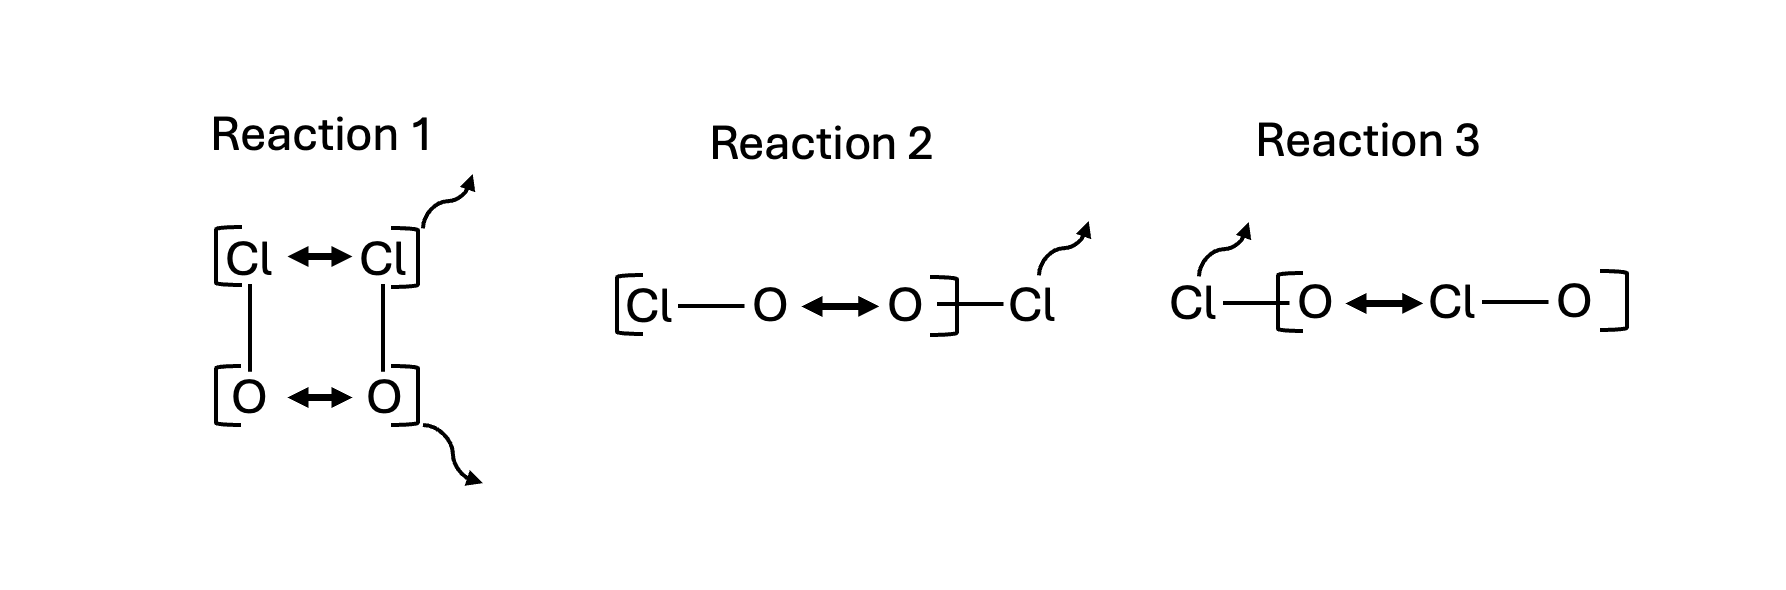

### Q2.6. Following is some thermodynamic data. Use it to sketch/dra/plot a potential enthalpy surface for the three reactions and a potential free energy surface for the three eactions at 298 K.

|     |  &emsp;&emsp; $\Delta H^{\circ}_{f}(298K)$ (kJ mol$^{-1}$) &emsp;&emsp;  |  &emsp;&emsp; $\Delta S^{\circ}_{f}(298K)$ (J mol$^{-1}$) &emsp;&emsp;  |
|:--------------------------------:|:----------------------------:|:-----------------------:|
| $\ce{ClO*}$  |  $101.22$  |  $226.65$  |
| $\ce{OClO*}$  |  $104.60$  |  $257.22$  |
| $\ce{ClO2}$  |  $98.0$  |  $269.32$  |
| $\ce{Cl}$  |  $121.3$  |  $165.19$  |
| $\ce{Cl2}$  |  $0$  |  $223.08$  |
| $\ce{O2}$  |  $0$  |  $205.15$  |

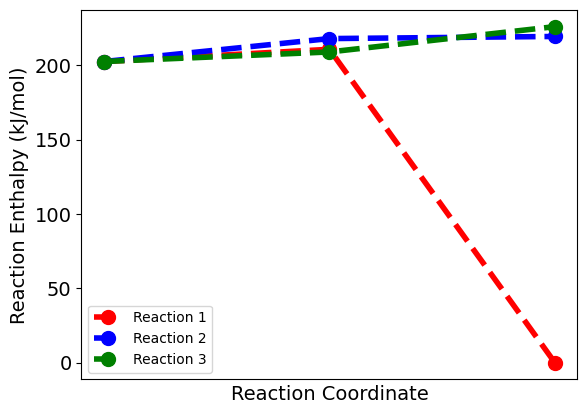

In [4]:
# Answer Here
# Enthalpy PES
H_ClO = 101.22
H_OClO = 104.60
H_ClO2 = 98.0
H_Cl = 121.3
H_Cl2 = 0
H_O2 = 0

H0_react = H_ClO * 2 # location of the reactants
H0_react_trans = H0_react + H0[42] # from question 2.3 (How does the TS change)
H0_prod =  H_Cl2 + H_O2

H1_react = H_ClO * 2 
H1_react_trans = H1_react + H1[42] 
H1_prod =  H_Cl + H_ClO2

H2_react = H_ClO * 2 
H2_react_trans = H2_react + H2[42] 
H2_prod =  H_Cl + H_OClO 


plt.plot([0,1,2],[H0_react,H0_react_trans,H0_prod],color='red',marker='o',
         markersize=10,linestyle='dashed',linewidth=4,label = 'Reaction 1')
plt.plot([0,1,2],[H1_react,H1_react_trans,H1_prod],color='blue',marker='o',
         markersize=10,linestyle='dashed',linewidth=4,label = 'Reaction 2')
plt.plot([0,1,2],[H2_react,H2_react_trans,H2_prod],color='green',marker='o',
         markersize=10,linestyle='dashed',linewidth=4,label = 'Reaction 3')
plt.legend()
plt.ylabel('Reaction Enthalpy (kJ/mol)',size=14)
plt.xlabel('Reaction Coordinate',size=14)
plt.xticks([])
plt.yticks(size=14)
plt.show()


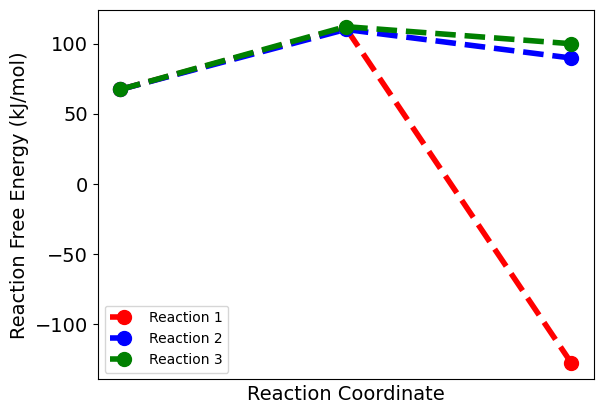

In [5]:
# Free Energy PES
G_ClO = H_ClO - (298*.22665) #kJ/mol
G_OClO = H_OClO - (298*.25722)
G_ClO2 = H_ClO2 - (298*.26932)
G_Cl = H_Cl - (298*.16519)
G_Cl2 = H_Cl2 - (298*.22308)
G_O2 = H_O2 - (298*.20515)

G0_react = (G_ClO*2)

G0 = H0[42] - (298*S0[42]/1000) + (G_ClO*2)
G1 = H1[42] - (298*S1[42]/1000) + (G_ClO*2)
G2 = H2[42] - (298*S2[42]/1000) + (G_ClO*2)

G0_prod = G_Cl2 + G_O2
G1_prod = G_Cl + G_ClO2
G2_prod = G_Cl + G_OClO

plt.plot([0,1,2],[G0_react,G0,G0_prod],color='red',marker='o',
         markersize=10,linestyle='dashed',linewidth=4,label = 'Reaction 1')
plt.plot([0,1,2],[G0_react,G1,G1_prod],color='blue',marker='o',
         markersize=10,linestyle='dashed',linewidth=4,label = 'Reaction 2')
plt.plot([0,1,2],[G0_react,G2,G2_prod],color='green',marker='o',
         markersize=10,linestyle='dashed',linewidth=4,label = 'Reaction 3')
plt.legend()
plt.ylabel('Reaction Free Energy (kJ/mol)',size=14)
plt.xlabel('Reaction Coordinate',size=14)
plt.xticks([])
plt.yticks(size=14)
plt.show()


# Q3. What do I get in compensation?
Following are some observed data for the dehydrogenation of $\textit{iso}$-propanol, $\ce{CH3CH(OH)CH3 -> CH3C(O)CH3 + H2}$, over a series of catalysts:

| &emsp;&emsp;$A$ (s$^{-1}$)&emsp;&emsp; | &emsp;&emsp;$E_{a}$ (kJ mol$^{-1}$)&emsp;&emsp; |
|:----------------------------:|:-----------------------:|
| $ 4.3\times10^{12}   $       |      $172$             |
| $ 2.3\times10^{11}  $        |      $159$             |
| $ 2.2\times10^{10}   $       |      $146$             |
| $ 1.6\times10^{9}   $        |      $134$             |

### Q3.1. What do you observe about the relationship between $\Delta H^{\circ,\ddagger}$ and $\Delta S^{\circ,\ddagger}$?

This relationship is called the "compensation effect," and its origins are widely debated.

### Arrhenius and Transition State Theory Relations

The rate constant is given by:

$$
k = A \, e^{-\frac{E_a}{RT}} = \frac{k_B T}{h} \, e^{\frac{\Delta S^\ddagger}{R}} \, e^{-\frac{\Delta H^\ddagger}{RT}}
$$

---

- $ E_a \approx \Delta H^\ddagger $ 
- $ \ln A = \ln\left(\frac{k_B T}{h}\right) + \frac{\Delta S^\ddagger}{R} $

---

Since:
$
\ln\left(\frac{k_B T}{h}\right) \approx 30
$
, we can write:
$
\Delta S^\ddagger = \left( \ln A - 30 \right) R
$

---

Therefore, to analyze, we plot:
$
\ln A \;\; \text{vs.} \;\; E_a
$
, since
$
k = A \, e^{-\frac{E_a}{RT}}
$

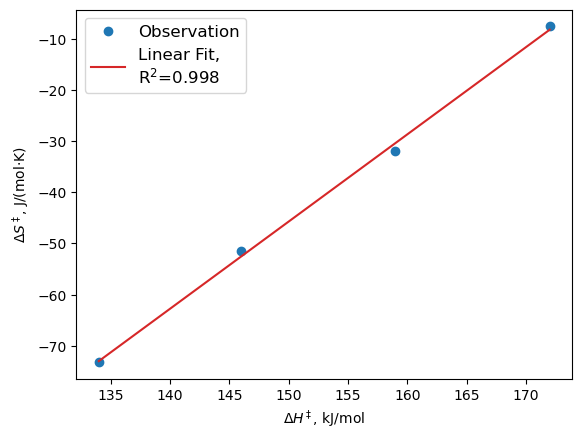

In [6]:
# Customize the figure to plot; just to make things pretty. Not mandatory.
from matplotlib.ticker import FormatStrFormatter
from matplotlib.pyplot import *
from sklearn.metrics import r2_score
A = np.array([4.3* 10**12,2.3* 10**11,2.2* 10**10,1.6* 10**9]) 
Ea = np.array([172,159,146,134])
lnA = np.log(A)
deltaH = Ea
deltaS = (lnA-30)*8.314
plt.plot(deltaH,deltaS, 'o', label = 'Observation')

# Fit the observations with a linear line
linear_model=np.polyfit(deltaH,deltaS,1)
linear_model_fn=np.poly1d(linear_model)
# x_s=np.arange(20,31)
# Plot and add R2 in the label
R2 = r2_score(linear_model_fn(deltaH),deltaS)
plt.plot(deltaH,linear_model_fn(deltaH),c='tab:red',label='Linear Fit, \nR$^2$={:.3f}'.format(R2))

plt.legend(fontsize=12)
plt.ylabel(r'$\Delta S^\ddagger$, J/(mol·K)')
plt.xlabel(r'$\Delta H^\ddagger$, kJ/mol')
plt.show()

We can say there is a compensation relationship between the apparent pre-exponential factor and apparent activation energy. There is likely a compensation relationship between $\Delta H^{\circ\ddagger}_{p}$ (transition state) and $\Delta S^{\circ\ddagger}$ (transition state) of the rate-controlling step.

### Q3.2. Would you expect the rate of the reaction to be different for fully deuterated $\ce{CH3CH(OH)CH3}$? If so, would you expect it to be faster or slower? Why, in terms of rate constant parameters?

(In class discussion about Toluene) The reaction would be slower for fully deuterated isopropanol. Replacing hydrogen with deuterium increases the activation energy due to lower zero-point energy (ZPE is proportional to 1/sqrt(m)) and reduces the pre-exponential factor because of lower vibrational frequency and tunneling. These effects decrease the rate constant $k = A e^{-E_a/RT}$, leading to a slower reaction — a primary kinetic isotope effect.

# Q4. It's too hot to stay here
Temperature-programmed desorption is a common way to explore the kinetics of the subtraction or addition of a molecule to a surface. You are going to do experiments to compare the associative desorption of $\ce{N2}$ from a series of metal surfaces: $\ce{2N* -> N2 + 2 *}. You have the (DFT-derived) data below.

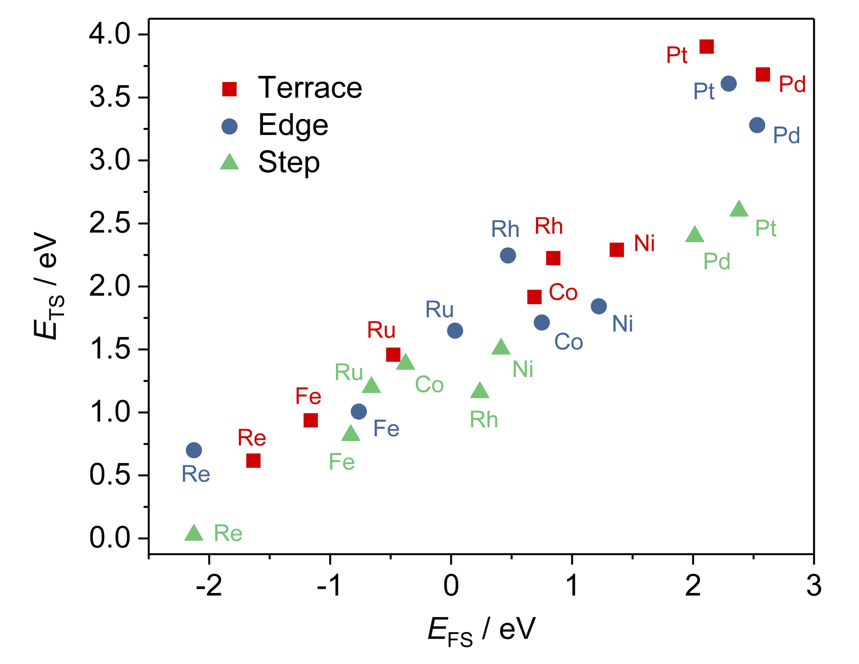

### Q4.1. Consider the results for the metal terraces. Do they follow a BEP relationship? If so, what is the approximate slope? How about the steps? What can you conclude about how "early" or "late" the transition state is on each site type? How confident are you?

We have to go off of data in a figure. It is good to practice.

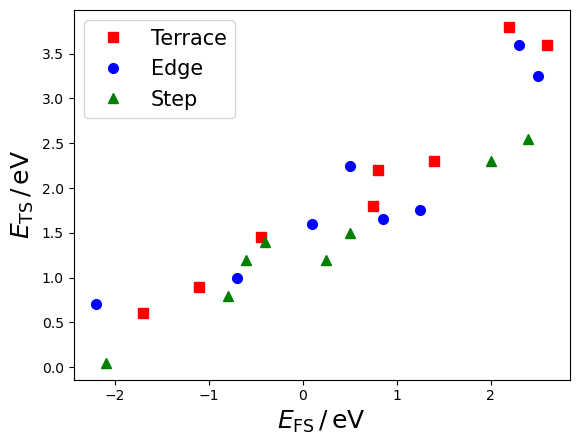

In [7]:
import pandas as pd
terrace = [
    (-1.7, 0.6), (-1.1, 0.9), (-0.45, 1.45), (0.75, 1.8),
    (0.8, 2.2), (1.4, 2.3), (2.2, 3.8), (2.6, 3.6)
]

edge = [
    (-2.2, 0.7), (-0.7, 1.0), (0.1, 1.6), (0.5, 2.25),
    (0.85, 1.65), (1.25, 1.75), (2.3, 3.6), (2.5, 3.25)
]

step = [
    (-2.1, 0.05), (-0.8, 0.8), (-0.6, 1.2), (-0.4, 1.4),
    (0.25, 1.2), (0.5, 1.5), (2, 2.3), (2.4, 2.55)
]

# Create DataFrames
df_terrace = pd.DataFrame(terrace, columns=["E_FS (eV)", "E_TS (eV)"])
df_edge = pd.DataFrame(edge, columns=["E_FS (eV)", "E_TS (eV)"])
df_step = pd.DataFrame(step, columns=["E_FS (eV)", "E_TS (eV)"])

# Combine into dictionary for easy access
datasets = {
    "Terrace": df_terrace,
    "Edge": df_edge,
    "Step": df_step
}

plt.plot(datasets['Terrace']['E_FS (eV)'],datasets['Terrace']['E_TS (eV)'], 'rs', label='Terrace', markersize=7)
plt.plot(datasets['Edge']['E_FS (eV)'],datasets['Edge']['E_TS (eV)'], 'bo', label='Edge', markersize=7)
plt.plot(datasets['Step']['E_FS (eV)'],datasets['Step']['E_TS (eV)'], 'g^', label='Step', markersize=7)
plt.xlabel(r'$E_{\mathrm{FS}}\,/\,\mathrm{eV}$', fontsize=18)
plt.ylabel(r'$E_{\mathrm{TS}}\,/\,\mathrm{eV}$', fontsize=18)
plt.legend(fontsize=15)
plt.show()

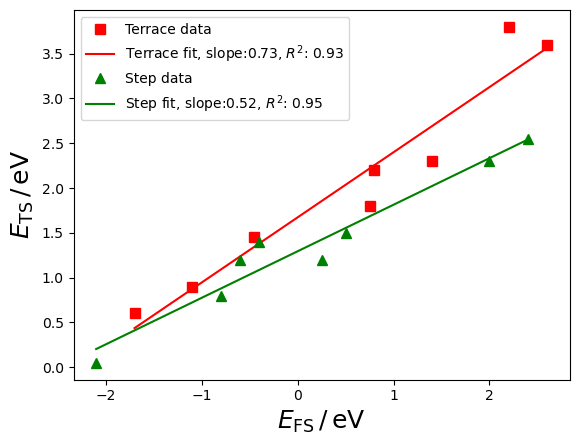

In [8]:
from scipy import stats
# Use 'stats' linear regression from scipy (easy to get slope, intercept, rvalue, pvalue, and stderr)
terrace_result = stats.linregress(datasets['Terrace']['E_FS (eV)'],datasets['Terrace']['E_TS (eV)'])
step_result = stats.linregress(datasets['Step']['E_FS (eV)'],datasets['Step']['E_TS (eV)'])

terrace_model = terrace_result.intercept + terrace_result.slope*datasets['Terrace']['E_FS (eV)']
step_model = step_result.intercept + step_result.slope*datasets['Step']['E_FS (eV)']
plt.figure()
plt.plot(datasets['Terrace']['E_FS (eV)'],datasets['Terrace']['E_TS (eV)'], 'rs', label='Terrace data', markersize=7)
plt.plot(datasets['Terrace']['E_FS (eV)'],terrace_model,'r-', label=f'Terrace fit, slope:{terrace_result.slope:.2f}, $R^2$: {terrace_result.rvalue**2:.2f}')
plt.plot(datasets['Step']['E_FS (eV)'],datasets['Step']['E_TS (eV)'], 'g^', label='Step data', markersize=7)
plt.plot(datasets['Step']['E_FS (eV)'],step_model,'g-', label=f'Step fit, slope:{step_result.slope:.2f}, $R^2$: {step_result.rvalue**2:.2f}')

plt.xlabel(r'$E_{\mathrm{FS}}\,/\,\mathrm{eV}$', fontsize=18)
plt.ylabel(r'$E_{\mathrm{TS}}\,/\,\mathrm{eV}$', fontsize=18)
plt.legend(fontsize=10)
plt.show()

Yes, the results for the metal terrace and step sites follow a BEP relationship ($R^2$s in both are greater than 0.9). The approximate slope for terrace dataset is about 0.73, which suggests a relatively late transition state — meaning the system has progressed closer to the final state before reaching the energy barrier. Whereas for the step sites, the slope is lower, about 0.52, which indicates an early transition state that occurs closer to the reactants. This means the transition state is less product-like compared to that on terraces.

### Q4.2. You prepare terraced surfaces of Re, Ru, and Ni with $\theta = 0.5$ ML of $\ce{N*}$ and perform temperature programmed desorption experiments starting at 300 K with a ramp rate of 5 K/s. Plot on the same graph the desorption rate vs temperature for each metal. Assume that the prefactor is a constant $10^{13}\mathrm{s}^{-1}$.

### Associative Desorption Kinetics

We define the activation energy for 'Desorption' (not Adsorption) as:

$$
\Delta E = E_{\mathrm{a,f}} - E_{\mathrm{a,r}}
$$

$$
E_{\mathrm{a,r}} = E_{\mathrm{a,f}} - \Delta E = E_{\mathrm{TS}} - E_{\mathrm{FS}}
$$

The rate equation for associative desorption is:

$$
r_{\mathrm{des}} = A \, e^{-\frac{E_{\mathrm{a,r}}}{k_B T}} \, \theta_N^2
$$

$$
\frac{d\theta_N}{dt} = -2*r_{\mathrm{des}}= - 2A \, e^{-\frac{E_{\mathrm{a,r}}}{k_B T}} \, \theta_N^2
$$

where the temperature is ramped linearly as:

$$
T = 300 + 5t \quad [\mathrm{K}]
$$

---

We can rearrange the differential equation as:

$$
\frac{d\theta_N}{\theta_N^2} = - 2A \, e^{-\frac{E_{\mathrm{a,r}}}{k_B T}} \, dt
$$

Integrating both sides from the initial coverage $\theta_{N,0}$ = 0.5 ML at $t=0$ to $\theta_N(t)$ at time $t$ gives:

$$
\int_{\theta_{N,0}}^{\theta_N} \frac{d\theta_N}{\theta_N^2} 
= - 2A \int_{0}^{t} e^{-\frac{E_{\mathrm{a,r}}}{k_B (300 + 5t)}} \, dt
$$

Solving this integral yields $\theta_N = \theta_N(t)$, the surface coverage as a function of time.

Once $\theta_N(t)$ is known, the desorption rate is:

$$
r_{\mathrm{des}}(t) = A \, e^{-\frac{E_{\mathrm{a,r}}}{k_B T}} \, \theta_N^2 [=] ML^2/s
$$

In [9]:
# Extract and save data for three metals
Re = datasets['Terrace'].iloc[0]
Ru = datasets['Terrace'].iloc[2]
Ni = datasets['Terrace'].iloc[5]

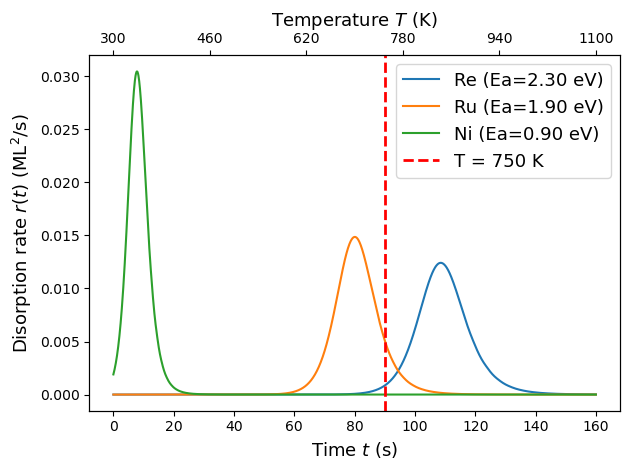

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

kB = 8.617333262e-5   # eV/K
A  = 1e13             # 1/s
theta0 = 0.5          # ML
T0 = 300.0            # K
beta = 5.0            # K/s, ramp rate of 5 K/s

def T_of_t(t): 
    return T0 + beta*t

# Ea = E_TS - E_FS
dE = {
    "Re": Re['E_TS (eV)'] - Re['E_FS (eV)'], 
    "Ru": Ru['E_TS (eV)'] - Ru['E_FS (eV)'],   
    "Ni": Ni['E_TS (eV)'] - Ni['E_FS (eV)']     
}
# ODE: dtheta/dt = -2A * exp(-Ea/(kB*T(t))) * theta^2
def rhs(t, y, dE_val):
    theta = max(y[0], 0.0)  # numerical guard
    return [-2 * A * np.exp(-dE_val / (kB * T_of_t(t))) * theta**2] # dtheta/dt, not r

# integrate from 300 K to 1100 K
T_end = 1100
t_end = (T_end - T0)/beta
t_eval = np.linspace(0.0, t_end, 2000)

solutions = {}
for metal, dE_val in dE.items():
    sol = solve_ivp(rhs, (0.0, t_end), [theta0],
                    t_eval=t_eval, args=(dE_val,)) # args: Additional arguments to pass to the user-defined functions (rhs fucntion above)
    solutions[metal] = sol

# Plot rate vs. time or temperature
fig, ax1 = plt.subplots()

for metal, sol in solutions.items():
    t = sol.t
    theta = sol.y[0]
    T = T_of_t(t)
    r = A * np.exp(-dE[metal] / (kB * T)) * theta**2
    ax1.plot(t, r, label=f'{metal} (Ea={dE[metal]:.2f} eV)')

ax1.set_xlabel(r'Time $t$ (s)', fontsize=13)
ax1.set_ylabel(r'Disorption rate $r(t)$ (ML$^2$/s)', fontsize=13)
# optional for the next question: vertical guide at T = 750 K  (t = 90 s)
t_target = (750 - T0)/beta
ax1.axvline(x=t_target, color='red', linestyle='--', linewidth=2, label='T = 750 K')
ax1.legend(fontsize=13)

# top x-axis with Temperature
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())
T_ticks = np.linspace(T_of_t(0), T_of_t(t_end), 6)
t_ticks = (T_ticks - T0)/beta
ax2.set_xticks(t_ticks)
ax2.set_xticklabels([f"{int(T)}" for T in T_ticks])
ax2.set_xlabel(r'Temperature $T$ (K)', fontsize=13)

plt.tight_layout()
plt.show()

### Q4.3. Ru is a good catalyst for the ${NH_3}$ synthesis reaction, which involves the opposite, dissociative adsorption of ${N_2}$ on a metal? Ru is a great catalyst for this reaction at the reaction temperature of about 750 K. Do the TPR results provide any useful insight into why Ru is a good choice?

At 750, the desorption rate for Ru is the highest, indicating that dissociated nitrogen atoms are readily combining to form ${N_2}$. At first glance, this might seem unfavorable for ammonia synthesis, since nitrogen is leaving the surface rather than participating in hydrogenation. However, it also suggests that the dissociated nitrogen atoms are not strongly bound to the Ru surface. This weaker binding means they are more likely to either recombine into ${N_2}$ (the reverse reaction) or participate in subsequent steps toward ${NH_3}$ formation (the forward pathway), depending on the reaction environment.